In [ ]:
!pip install segmentation-models-pytorch albumentations --quiet
!pip install opencv-python matplotlib --upgrade --quiet
!pip install torch torchvision --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 70.0 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import segmentation_models_pytorch as smp
from segmentation_models_pytorch import Unet
from sklearn.model_selection import train_test_split, KFold
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingWarmRestarts
import time
import random
import torch.nn.functional as F
import torch
import gc


/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.6' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de: {device}")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
BASE_PATH = '/content/drive/MyDrive/archive'
IMG_SIZE = 512
BATCH_SIZE = 8
NUM_WORKERS = 4
NUM_EPOCHS = 30
LEARNING_RATE = 3e-4
NUM_CLASSES = 3
PATIENCE = 10
K_FOLDS = 5

In [ ]:
!pip install segmentation-models-pytorch albumentations --quiet
!pip install opencv-python matplotlib --upgrade --quiet
!pip install torch torchvision --quiet

from google.colab import drive
drive.mount('/content/drive')
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import segmentation_models_pytorch as smp
from segmentation_models_pytorch import Unet
from sklearn.model_selection import train_test_split, KFold
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingWarmRestarts
import time
import random
import torch.nn.functional as F
import torch
import gc
import os

LEARNING_RATE = 3e-4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de: {device}")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
BASE_PATH = '/content/drive/MyDrive/archive'
IMG_SIZE = 512
BATCH_SIZE = 8
NUM_WORKERS = 4
NUM_EPOCHS = 50

NUM_CLASSES = 3
PATIENCE = 10
K_FOLDS = 5

def free_memory():
    """Libère la mémoire GPU et CPU de manière agressive"""
    gc.collect()
    torch.cuda.empty_cache()
    if torch.cuda.is_available():
        # Afficher les stats de mémoire
        print(f"Mémoire GPU utilisée: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
        print(f"Mémoire GPU réservée: {torch.cuda.memory_reserved() / 1e9:.2f} GB")

def create_model_lightweight():
    """
    Crée un modèle UNet avec un encodeur plus léger pour économiser la mémoire GPU
    """
    # Utiliser des encodeurs moins gourmands en mémoire
    lightweight_encoders = [
        "mobilenet_v2",       # ~14M paramètres, très léger
        "efficientnet-b0",    # ~20M paramètres, bon compromis taille/performance
        "resnet18"            # ~11M paramètres, plus léger que resnet50
    ]
    model_name = random.choice(lightweight_encoders)

    print(f"Utilisation de l'architecture légère {model_name} comme encodeur")

    # Ajout d'option pour réduire la complexité du décodeur
    decoder_channels = [256, 128, 64, 32]  # Moins de canaux dans le décodeur

    model = Unet(
        encoder_name=model_name,
        encoder_weights="imagenet",
        in_channels=3,
        classes=NUM_CLASSES + 1,
        decoder_channels=decoder_channels,
        decoder_attention_type="se"
    )

    return model.to(device)

def use_mixed_precision():
    """
    Configure PyTorch pour utiliser la précision mixte automatique
    et réduire la consommation de mémoire GPU
    """
    # Vérifier si la précision mixte est disponible (CUDA >= 10.1)
    if not torch.cuda.is_available():
        print("⚠️ GPU non disponible. Précision mixte désactivée.")
        return None

    # Vérifier la version de CUDA
    cuda_version = torch.version.cuda
    if cuda_version is None:
        print("⚠️ CUDA non disponible. Précision mixte désactivée.")
        return None

    try:
        major, minor = map(int, cuda_version.split('.')[:2])
        if major < 10 or (major == 10 and minor < 1):
            print(f"⚠️ CUDA {cuda_version} détecté. Précision mixte nécessite CUDA >= 10.1.")
            return None
    except:
        print(f"⚠️ Impossible de déterminer la version CUDA. Précision mixte pourrait ne pas fonctionner.")

    # Créer et retourner un scaler pour la précision mixte
    print("✅ Précision mixte automatique activée (AMP)")
    return torch.cuda.amp.GradScaler()

def configure_colab_for_gpu():
    """
    Configure l'environnement Colab pour maximiser les performances GPU
    """
    # Vérifier le type de GPU disponible
    import subprocess
    gpu_info = subprocess.check_output('nvidia-smi', shell=True).decode('utf-8')
    print("🔍 GPU disponible:")
    print(gpu_info)

    # Afficher la mémoire disponible
    if torch.cuda.is_available():
        print(f"✅ GPU disponible: {torch.cuda.get_device_name(0)}")
        print(f"📊 Mémoire GPU totale: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
        print(f"📊 Mémoire GPU allouée: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
        print(f"📊 Mémoire GPU réservée: {torch.cuda.memory_reserved() / 1e9:.2f} GB")
    else:
        print("❌ GPU non disponible. L'entraînement sera très lent.")

    # Définir les paramètres optimaux pour Colab
    torch.backends.cudnn.benchmark = True  # Accélération pour tailles d'entrée constantes

    # Libérer la mémoire cache
    import gc
    gc.collect()
    torch.cuda.empty

def reduce_precision():
    """Configure PyTorch pour utiliser la précision mixte"""
    if torch.cuda.is_available():
        # Activer la précision mixte automatique
        return torch.cuda.amp.GradScaler()
    return None

def optimize_dataloader(dataset, batch_size=4, num_workers=2):
    """Crée un DataLoader optimisé pour la mémoire"""
    return torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True if isinstance(dataset, torch.utils.data.Dataset) else False,
        num_workers=num_workers,
        pin_memory=True,
        prefetch_factor=2
    )
def get_file_paths():
    """
    Parcourt le dossier archive pour récupérer les chemins des images et leurs annotations correspondantes
    """
    image_paths = []
    annotation_paths = []

    # Explorer le dossier pour trouver les images et les annotations
    for root, _, files in os.walk(BASE_PATH):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):  # Ajout de .png
                image_path = os.path.join(root, file)

                # Construire le chemin du fichier d'annotation correspondant
                annotation_file = os.path.splitext(file)[0] + '.txt'
                annotation_path = os.path.join(root, annotation_file)

                # Vérifier si le fichier d'annotation existe
                if os.path.exists(annotation_path):
                    image_paths.append(image_path)
                    annotation_paths.append(annotation_path)

    print(f"Nombre total d'images avec annotations: {len(image_paths)}")
    return image_paths, annotation_paths
def yolo_to_mask(image_path, annotation_path):
    """
    Convertit les annotations YOLO en masques pour la segmentation

    Args:
        image_path: Chemin vers l'image
        annotation_path: Chemin vers le fichier d'annotation YOLO

    Returns:
        mask: Masque multi-classe (H, W) avec valeurs 0, 1, 2, 3 (fond + 3 classes)
    """
    # Chargement de l'image pour obtenir ses dimensions
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape

    # Création d'un masque vide (0 = fond)
    mask = np.zeros((h, w), dtype=np.uint8)

    # Lecture des annotations YOLO
    try:
        with open(annotation_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:  # Format YOLO: class x_center y_center width height
                    class_id = int(parts[0]) + 1  # +1 car 0 est réservé pour le fond
                    x_center = float(parts[1]) * w
                    y_center = float(parts[2]) * h
                    box_width = float(parts[3]) * w
                    box_height = float(parts[4]) * h

                    # Calcul des coordonnées du rectangle
                    x1 = int(x_center - box_width / 2)
                    y1 = int(y_center - box_height / 2)
                    x2 = int(x_center + box_width / 2)
                    y2 = int(y_center + box_height / 2)

                    # S'assurer que les coordonnées sont dans les limites de l'image
                    x1, y1 = max(0, x1), max(0, y1)
                    x2, y2 = min(w-1, x2), min(h-1, y2)

                    # Créer un rectangle rempli dans le masque avec la valeur de la classe
                    cv2.rectangle(mask, (x1, y1), (x2, y2), class_id, -1)  # -1 signifie remplir
    except Exception as e:
        print(f"Erreur lors de la lecture du fichier d'annotation {annotation_path}: {e}")
        return mask

    return mask

class SkinBurnDataset(Dataset):
    def __init__(self, image_paths, annotation_paths, transforms=None):
        self.image_paths = image_paths
        self.annotation_paths = annotation_paths
        self.transforms = transforms

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        annotation_path = self.annotation_paths[idx]

        # Chargement de l'image
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Création du masque à partir des annotations YOLO
        mask = yolo_to_mask(image_path, annotation_path)

        # Application des transformations si spécifiées
        if self.transforms:
            transformed = self.transforms(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]

        # Conversion du masque en one-hot encoding pour la segmentation multi-classe
        mask_tensor = torch.zeros(NUM_CLASSES + 1, mask.shape[0], mask.shape[1])  # +1 pour le fond
        for i in range(NUM_CLASSES + 1):
            mask_tensor[i] = (mask == i).float()

        return image, mask_tensor
def get_augmentations():
    """
    Crée des augmentations plus avancées pour améliorer la généralisation
    """
    # Transformations pour l'augmentation des données (entraînement)
    train_transforms = A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.OneOf([
            A.HorizontalFlip(p=0.8),
            A.VerticalFlip(p=0.8),
            A.RandomRotate90(p=0.8),
        ], p=0.8),
        A.OneOf([
            A.ElasticTransform(alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03, p=0.5),
            A.GridDistortion(p=0.5),
            A.OpticalDistortion(distort_limit=2, shift_limit=0.5, p=0.5),
        ], p=0.3),
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
            A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.5),
            A.CLAHE(clip_limit=4.0, p=0.5),
        ], p=0.8),
        A.OneOf([
            A.GaussNoise(p=0.5),
            A.GaussianBlur(p=0.5),
            A.MotionBlur(p=0.5),
        ], p=0.3),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.5),
        A.Normalize(),
        ToTensorV2()
    ])

    # Transformations pour la validation
    val_transforms = A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(),
        ToTensorV2()
    ])

    return train_transforms, val_transforms

class DiceBCEFocalLoss(nn.Module):
    """
    Combinaison de Dice Loss, BCE et Focal Loss pour une meilleure gestion des déséquilibres
    """
    def __init__(self, alpha=0.5, gamma=2.0, weight=None):
        super(DiceBCEFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(weight=weight)

    def forward(self, inputs, targets):
        # BCE Loss
        bce_loss = self.bce(inputs, targets)

        # Focal Loss component - Correction avec .detach() pour éviter l'erreur
        inputs_sigmoid = torch.sigmoid(inputs)
        focal_weight = ((1 - inputs_sigmoid) * targets + inputs_sigmoid * (1 - targets))
        focal_weight = torch.pow(focal_weight, self.gamma).detach()  # .detach() pour empêcher le calcul de gradient

        # Correction de focal_loss
        focal_loss = F.binary_cross_entropy_with_logits(inputs, targets, weight=focal_weight)

        # Dice Loss
        inputs_sigmoid = torch.sigmoid(inputs)
        inputs_sigmoid = inputs_sigmoid.view(-1)
        targets_flat = targets.view(-1)
        intersection = (inputs_sigmoid * targets_flat).sum()
        dice_loss = 1 - (2. * intersection) / (inputs_sigmoid.sum() + targets_flat.sum() + 1e-6)

        # Combinaison des trois pertes
        return 0.4 * bce_loss + 0.4 * dice_loss + 0.2 * focal_loss
class EarlyStopping:
    """
    Early stopping pour éviter le surapprentissage
    """
    def __init__(self, patience=7, delta=0.001, checkpoint_path='best_model.pt'):
        self.patience = patience
        self.delta = delta
        self.checkpoint_path = checkpoint_path
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        print(f'Validation loss decreased ({self.best_score:.6f} --> {-val_loss:.6f}). Saving model...')
        torch.save(model.state_dict(), self.checkpoint_path)

def calculate_accuracy(pred, target, threshold=0.5):
    """
    Calcule la précision de la segmentation
    """
    pred = torch.sigmoid(pred) > threshold
    target = target > 0.5

    correct = (pred == target).float().sum()
    total = torch.numel(pred)

    return (correct / total).item() * 100

def calculate_class_metrics(pred, target, threshold=0.5):
    """
    Calcule les métriques par classe: précision, recall et f1-score
    """
    pred = torch.sigmoid(pred) > threshold
    target = target > 0.5

    metrics = {}

    # Pour chaque classe
    for cls in range(target.shape[1]):
        pred_cls = pred[:, cls, :, :]
        target_cls = target[:, cls, :, :]

        # Calcul des TP, FP, FN
        tp = torch.logical_and(pred_cls, target_cls).sum().float().item()
        fp = torch.logical_and(pred_cls, torch.logical_not(target_cls)).sum().float().item()
        fn = torch.logical_and(torch.logical_not(pred_cls), target_cls).sum().float().item()

        # Calcul des métriques
        precision = tp / (tp + fp + 1e-10)
        recall = tp / (tp + fn + 1e-10)
        f1 = 2 * precision * recall / (precision + recall + 1e-10)

        metrics[f"class_{cls}"] = {
            "precision": precision * 100,
            "recall": recall * 100,
            "f1_score": f1 * 100
        }

    return metrics

def calculate_iou(pred, target, threshold=0.5):
    """
    Calcule l'IoU (Intersection over Union) pour chaque classe
    """
    pred = torch.sigmoid(pred) > threshold
    target = target > 0.5

    ious = []

    # Pour chaque classe
    for cls in range(target.shape[1]):
        pred_cls = pred[:, cls, :, :]
        target_cls = target[:, cls, :, :]

        intersection = (pred_cls & target_cls).float().sum((1, 2))
        union = (pred_cls | target_cls).float().sum((1, 2))

        iou = (intersection + 1e-10) / (union + 1e-10)
        ious.append(iou.mean().item())

    class_ious = {f"iou_class_{i}": ious[i] for i in range(len(ious))}
    class_ious["mean_iou"] = np.mean(ious)

    return class_ious



def create_model():
    """
    Crée un modèle UNet amélioré pour la segmentation des brûlures cutanées
    """
    # Utiliser un encodeur plus performant
    encoders = ["resnet50", "efficientnet-b4", "se_resnext50_32x4d"]
    model_name = random.choice(encoders)  # Choisir aléatoirement un encodeur

    print(f"Utilisation de l'architecture {model_name} comme encodeur")

    model = Unet(
        encoder_name=model_name,
        encoder_weights="imagenet",
        in_channels=3,
        classes=NUM_CLASSES + 1,  # Nombre de classes + fond
        decoder_attention_type="scse"  # Ajout de l'attention spatiale et de canal
    )

    return model.to(device)

def optimized_train_epoch(model, dataloader, criterion, optimizer, device, scheduler=None, scaler=None, accumulation_steps=2):
    """
    Fonction d'entraînement optimisée pour une époque avec accumulation de gradients et précision mixte
    """
    model.train()
    epoch_loss = 0
    epoch_iou = 0
    epoch_accuracy = 0

    # Progress bar pour l'entraînement
    loop = tqdm(dataloader, desc="Entraînement")

    optimizer.zero_grad()  # Réinitialiser les gradients au début

    for idx, (images, masks) in enumerate(loop):
        images = images.to(device)
        masks = masks.to(device)

        # Utiliser la précision mixte si disponible
        if scaler is not None:
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, masks)

                # Normaliser la perte
                loss = loss / accumulation_steps

            # Backward pass avec scaling
            scaler.scale(loss).backward()

            # Optimisation après accumulation
            if (idx + 1) % accumulation_steps == 0 or idx == len(dataloader) - 1:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
        else:
            # Mode standard sans précision mixte
            outputs = model(images)
            loss = criterion(outputs, masks)

            # Normaliser la perte
            loss = loss / accumulation_steps

            # Backward pass
            loss.backward()

            # Optimisation après accumulation
            if (idx + 1) % accumulation_steps == 0 or idx == len(dataloader) - 1:
                optimizer.step()
                optimizer.zero_grad()

        # Détacher les tenseurs pour libérer de la mémoire
        with torch.no_grad():
            # Utiliser .detach() pour éviter de garder les gradients en mémoire
            current_loss = loss.item() * accumulation_steps  # Dénormaliser pour l'affichage
            epoch_loss += current_loss

            # Calculer les métriques avec les tenseurs détachés
            outputs_detached = outputs.detach()
            masks_detached = masks.detach()

            current_iou = calculate_iou(outputs_detached, masks_detached)["mean_iou"]
            epoch_iou += current_iou

            current_accuracy = calculate_accuracy(outputs_detached, masks_detached)
            epoch_accuracy += current_accuracy

            # Libérer les variables temporaires
            del outputs_detached, masks_detached

        # Mise à jour de la progress bar avec moins de détails pour économiser la RAM
        if idx % 5 == 0:  # Mettre à jour moins souvent
            loop.set_postfix(loss=current_loss)

        # Scheduler step si fourni
        if scheduler is not None and not isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau) and (idx + 1) % accumulation_steps == 0:
            scheduler.step()

    metrics = {
        "loss": epoch_loss / len(dataloader),
        "iou": epoch_iou / len(dataloader),
        "accuracy": epoch_accuracy / len(dataloader)
    }

    return metrics
def validate_epoch(model, dataloader, criterion, device):
    """
    Fonction d'évaluation pour une époque
    """
    model.eval()
    val_loss = 0
    val_iou = 0
    val_accuracy = 0
    val_metrics = {}

    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="Validation"):
            images = images.to(device)
            masks = masks.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, masks)

            # Mise à jour des métriques
            val_loss += loss.item()

            # IoU
            iou_metrics = calculate_iou(outputs, masks)
            val_iou += iou_metrics["mean_iou"]

            # Accuracy
            val_accuracy += calculate_accuracy(outputs, masks)

            # Métriques par classe
            class_metrics = calculate_class_metrics(outputs, masks)

            # Mettre à jour le dictionnaire des métriques
            for cls, metrics in class_metrics.items():
                if cls not in val_metrics:
                    val_metrics[cls] = {"precision": 0, "recall": 0, "f1_score": 0}
                val_metrics[cls]["precision"] += metrics["precision"]
                val_metrics[cls]["recall"] += metrics["recall"]
                val_metrics[cls]["f1_score"] += metrics["f1_score"]

    # Moyenner les métriques
    for cls in val_metrics:
        val_metrics[cls]["precision"] /= len(dataloader)
        val_metrics[cls]["recall"] /= len(dataloader)
        val_metrics[cls]["f1_score"] /= len(dataloader)

    metrics = {
        "loss": val_loss / len(dataloader),
        "iou": val_iou / len(dataloader),
        "accuracy": val_accuracy / len(dataloader),
        "class_metrics": val_metrics
    }

    return metrics

def patch_train_and_validate():
    """
    Remplace la fonction train_and_validate par une version optimisée pour la mémoire
    à importer dans votre code principal
    """
    def optimized_train_and_validate(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, checkpoint_path):
        """
        Version optimisée pour la mémoire de train_and_validate
        """
        training_start = time.time()
        history = {
            "train_loss": [], "train_iou": [], "train_accuracy": [],
            "val_loss": [], "val_iou": [], "val_accuracy": [],
            "val_class_metrics": []
        }

        early_stopping = EarlyStopping(patience=PATIENCE, checkpoint_path=checkpoint_path)
        scaler = reduce_precision()  # Utiliser la précision mixte

        for epoch in range(num_epochs):
            print(f"\nÉpoque {epoch+1}/{num_epochs}")

            # Libérer la mémoire avant chaque époque
            free_memory()

            # Entraînement avec précision mixte
            train_metrics = optimized_train_epoch(model, train_loader, criterion, optimizer, device, scheduler, scaler)

            # Libérer la mémoire avant validation
            free_memory()

            # Validation
            val_metrics = optimized_validate_epoch(model, val_loader, criterion, device)

            # Mise à jour du learning rate
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_metrics["loss"])

            # Afficher les métriques
            print(f"Train Loss: {train_metrics['loss']:.4f}, Train IoU: {train_metrics['iou']:.4f}, Train Accuracy: {train_metrics['accuracy']:.2f}%")
            print(f"Val Loss: {val_metrics['loss']:.4f}, Val IoU: {val_metrics['iou']:.4f}, Val Accuracy: {val_metrics['accuracy']:.2f}%")

            # Afficher les métriques par classe mais limiter aux 3 principales pour économiser de la mémoire
            print("\nMétriques par classe (top 3):")
            cls_metrics = list(val_metrics["class_metrics"].items())
            for cls, metrics in cls_metrics[:3]:
                print(f"{cls} - P: {metrics['precision']:.2f}%, R: {metrics['recall']:.2f}%, F1: {metrics['f1_score']:.2f}%")

            # Mise à jour de l'historique
            history["train_loss"].append(train_metrics["loss"])
            history["train_iou"].append(train_metrics["iou"])
            history["train_accuracy"].append(train_metrics["accuracy"])
            history["val_loss"].append(val_metrics["loss"])
            history["val_iou"].append(val_metrics["iou"])
            history["val_accuracy"].append(val_metrics["accuracy"])
            history["val_class_metrics"].append(val_metrics["class_metrics"])

            # Early stopping
            early_stopping(val_metrics["loss"], model)
            if early_stopping.early_stop:
                print("Early stopping")
                break

        # Calcul du temps d'entraînement
        training_time = time.time() - training_start
        print(f"\nTemps d'entraînement total: {training_time / 60:.2f} minutes")

        try:
            # Charger le meilleur modèle
            model.load_state_dict(torch.load(checkpoint_path))
        except:
            print("Impossible de charger le meilleur modèle, utilisation du modèle actuel")

        return model, history

    return optimized_train_and_validate

def plot_training_history(history):
    """
    Visualise l'historique d'entraînement
    """
    plt.figure(figsize=(16, 12))

    # Plot de la perte
    plt.subplot(2, 2, 1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.title("Loss Evolution")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Plot de l'IoU
    plt.subplot(2, 2, 2)
    plt.plot(history["train_iou"], label="Train IoU")
    plt.plot(history["val_iou"], label="Val IoU")
    plt.title("IoU Evolution")
    plt.xlabel("Epoch")
    plt.ylabel("IoU")
    plt.legend()

    # Plot de la précision
    plt.subplot(2, 2, 3)
    plt.plot(history["train_accuracy"], label="Train Accuracy")
    plt.plot(history["val_accuracy"], label="Val Accuracy")
    plt.title("Accuracy Evolution")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()

    # Plot des métriques F1 par classe
    plt.subplot(2, 2, 4)
    for cls in history["val_class_metrics"][0].keys():
        f1_scores = [metrics[cls]["f1_score"] for metrics in history["val_class_metrics"]]
        plt.plot(f1_scores, label=f"{cls} F1")
    plt.title("F1 Score by Class")
    plt.xlabel("Epoch")
    plt.ylabel("F1 Score (%)")
    plt.legend()

    plt.tight_layout()
    plt.savefig("training_history.png")
    plt.show()

def visualize_predictions(model, val_loader, num_samples=5):
    """
    Visualise les prédictions du modèle sur quelques exemples
    """
    model.eval()

    plt.figure(figsize=(15, num_samples * 5))

    with torch.no_grad():
        for i, (images, masks) in enumerate(val_loader):
            if i >= num_samples:
                break

            images = images.to(device)
            masks = masks.to(device)

            # Forward pass
            outputs = model(images)

            # Traitement des images et des masques pour la visualisation
            image = images[0].cpu().permute(1, 2, 0).numpy()
            image = np.clip(image * 0.229 + 0.485, 0, 1)  # Denormalize

            true_mask = masks[0].cpu().numpy().argmax(0)
            pred_mask = torch.sigmoid(outputs[0]).cpu().numpy().argmax(0)

            # Visualisation
            plt.subplot(num_samples, 3, i * 3 + 1)
            plt.imshow(image)
            plt.title("Image")
            plt.axis("off")

            plt.subplot(num_samples, 3, i * 3 + 2)
            plt.imshow(true_mask, cmap='viridis')
            plt.title("Vrai Masque")
            plt.axis("off")

            plt.subplot(num_samples, 3, i * 3 + 3)
            plt.imshow(pred_mask, cmap='viridis')
            plt.title("Prédiction")
            plt.axis("off")

    plt.tight_layout()
    plt.savefig("predictions_visualization.png")
    plt.show()

def optimized_train_epoch(model, dataloader, criterion, optimizer, device, scheduler=None, scaler=None, accumulation_steps=2):
    """
    Fonction d'entraînement optimisée pour une époque avec accumulation de gradients et précision mixte
    """
    model.train()
    epoch_loss = 0
    epoch_iou = 0
    epoch_accuracy = 0

    # Progress bar pour l'entraînement
    loop = tqdm(dataloader, desc="Entraînement")

    optimizer.zero_grad()  # Réinitialiser les gradients au début

    for idx, (images, masks) in enumerate(loop):
        images = images.to(device)
        masks = masks.to(device)

        # Utiliser la précision mixte si disponible
        if scaler is not None:
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, masks)

                # Normaliser la perte
                loss = loss / accumulation_steps

            # Backward pass avec scaling
            scaler.scale(loss).backward()

            # Optimisation après accumulation
            if (idx + 1) % accumulation_steps == 0 or idx == len(dataloader) - 1:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
        else:
            # Mode standard sans précision mixte
            outputs = model(images)
            loss = criterion(outputs, masks)

            # Normaliser la perte
            loss = loss / accumulation_steps

            # Backward pass
            loss.backward()

            # Optimisation après accumulation
            if (idx + 1) % accumulation_steps == 0 or idx == len(dataloader) - 1:
                optimizer.step()
                optimizer.zero_grad()

        # Détacher les tenseurs pour libérer de la mémoire
        with torch.no_grad():
            # Utiliser .detach() pour éviter de garder les gradients en mémoire
            current_loss = loss.item() * accumulation_steps  # Dénormaliser pour l'affichage
            epoch_loss += current_loss

            # Calculer les métriques avec les tenseurs détachés
            outputs_detached = outputs.detach()
            masks_detached = masks.detach()

            current_iou = calculate_iou(outputs_detached, masks_detached)["mean_iou"]
            epoch_iou += current_iou

            current_accuracy = calculate_accuracy(outputs_detached, masks_detached)
            epoch_accuracy += current_accuracy

            # Libérer les variables temporaires
            del outputs_detached, masks_detached

        # Mise à jour de la progress bar avec moins de détails pour économiser la RAM
        if idx % 5 == 0:  # Mettre à jour moins souvent
            loop.set_postfix(loss=current_loss)

        # Scheduler step si fourni
        if scheduler is not None and not isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau) and (idx + 1) % accumulation_steps == 0:
            scheduler.step()

    metrics = {
        "loss": epoch_loss / len(dataloader),
        "iou": epoch_iou / len(dataloader),
        "accuracy": epoch_accuracy / len(dataloader)
    }

    return metrics

def optimized_validate_epoch(model, dataloader, criterion, device):
    """
    Fonction d'évaluation optimisée pour une époque
    """
    model.eval()
    val_loss = 0
    val_iou = 0
    val_accuracy = 0
    val_metrics = {}

    # Utiliser moins d'échantillons pour économiser de la mémoire
    subset_len = min(len(dataloader), 50)  # Limiter à 50 batchs maximum

    with torch.no_grad():
        for i, (images, masks) in enumerate(tqdm(dataloader, desc="Validation", total=subset_len)):
            if i >= subset_len:
                break

            images = images.to(device)
            masks = masks.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, masks)

            # Mise à jour des métriques
            val_loss += loss.item()

            # IoU
            iou_metrics = calculate_iou(outputs, masks)
            val_iou += iou_metrics["mean_iou"]

            # Accuracy
            val_accuracy += calculate_accuracy(outputs, masks)

            # Métriques par classe (limiter si trop de classes)
            class_metrics = calculate_class_metrics(outputs, masks)

            # Mettre à jour le dictionnaire des métriques (limiter aux 5 classes principales)
            top_classes = list(class_metrics.keys())[:min(5, len(class_metrics))]
            for cls in top_classes:
                metrics = class_metrics[cls]
                if cls not in val_metrics:
                    val_metrics[cls] = {"precision": 0, "recall": 0, "f1_score": 0}
                val_metrics[cls]["precision"] += metrics["precision"]
                val_metrics[cls]["recall"] += metrics["recall"]
                val_metrics[cls]["f1_score"] += metrics["f1_score"]

            # Libérer la mémoire explicitement
            del images, masks, outputs

            # Libérer mémoire occasionnellement
            if i % 10 == 0:
                torch.cuda.empty_cache()

    # Moyenner les métriques
    divisor = min(len(dataloader), subset_len)
    for cls in val_metrics:
        val_metrics[cls]["precision"] /= divisor
        val_metrics[cls]["recall"] /= divisor
        val_metrics[cls]["f1_score"] /= divisor

    metrics = {
        "loss": val_loss / divisor,
        "iou": val_iou / divisor,
        "accuracy": val_accuracy / divisor,
        "class_metrics": val_metrics
    }

    return metrics

def main():


    # Remplacer la fonction train_and_validate par notre version optimisée
    train_and_validate = patch_train_and_validate()

    # Libérer la mémoire au début
    free_memory()

    # Récupération des chemins des fichiers
    image_paths, annotation_paths = get_file_paths()

    # Vérifier si les données sont disponibles
    if len(image_paths) == 0:
        print("Aucune paire image-annotation trouvée. Vérifiez le chemin des données.")
        return

    # Taille d'image réduite pour économiser la mémoire
    global IMG_SIZE
    IMG_SIZE_REDUCED = 384  # Au lieu de 512
    IMG_SIZE = IMG_SIZE_REDUCED
    print(f"Utilisation d'une taille d'image réduite: {IMG_SIZE_REDUCED}x{IMG_SIZE_REDUCED}")

    # Obtenir les transformations pour l'augmentation des données
    train_transforms, val_transforms = get_augmentations()

    # Réduire le nombre de folds si problème de mémoire
    effective_k_folds = min(K_FOLDS, 3)  # Maximum 3 folds pour économiser de la mémoire
    if effective_k_folds < K_FOLDS:
        print(f"⚠️ Réduction du nombre de folds de {K_FOLDS} à {effective_k_folds} pour économiser la mémoire")

    # Validation croisée
    kfold = KFold(n_splits=effective_k_folds, shuffle=True, random_state=SEED)

    # Réduire la taille du batch
    REDUCED_BATCH_SIZE = 4  # Réduire le batch size (ajuster selon votre GPU)
    print(f"⚠️ Réduction de la taille du batch à {REDUCED_BATCH_SIZE}")

    # Tableaux pour stocker les résultats de chaque fold
    fold_results = {
        "val_loss": [],
        "val_iou": [],
        "val_accuracy": []
    }

    # Pour chaque fold
    for fold, (train_idx, val_idx) in enumerate(kfold.split(image_paths)):
        print(f"\n{'='*50}")
        print(f"Fold {fold+1}/{effective_k_folds}")
        print(f"{'='*50}")

        # Libérer la mémoire avant chaque fold
        free_memory()

        # Si la mémoire est vraiment critique, réduire la taille du dataset d'entraînement
        if fold > 0:  # Pour le premier fold, utiliser toutes les données
            train_idx = train_idx[:len(train_idx)//4*3]  # Utiliser 75% des données d'entraînement
            print(f"⚠️ Utilisation de {len(train_idx)} échantillons d'entraînement (75%)")

        # Préparation des données pour ce fold
        train_img_paths = [image_paths[i] for i in train_idx]
        train_anno_paths = [annotation_paths[i] for i in train_idx]
        val_img_paths = [image_paths[i] for i in val_idx]
        val_anno_paths = [annotation_paths[i] for i in val_idx]

        # Création des datasets
        train_dataset = SkinBurnDataset(train_img_paths, train_anno_paths, transforms=train_transforms)
        val_dataset = SkinBurnDataset(val_img_paths, val_anno_paths, transforms=val_transforms)

        # Création des dataloaders optimisés
        train_loader = optimize_dataloader(
            train_dataset,
            batch_size=REDUCED_BATCH_SIZE,
            num_workers=2  # Réduire le nombre de workers
        )

        val_loader = optimize_dataloader(
            val_dataset,
            batch_size=REDUCED_BATCH_SIZE,
            num_workers=2  # Réduire le nombre de workers
        )

        print(f"Taille de l'ensemble d'entraînement: {len(train_dataset)}")
        print(f"Taille de l'ensemble de validation: {len(val_dataset)}")

        # Initialisation du modèle
        model = create_model()  # Utiliser le modèle léger pour économiser la mémoire

        # Définition de la fonction de perte et de l'optimiseur
        criterion = DiceBCEFocalLoss()
        optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

        # Définition du scheduler
        scheduler = CosineAnnealingWarmRestarts(
            optimizer,
            T_0=10,
            T_mult=1,
            eta_min=1e-6
        )

        # Entraînement et validation avec précision mixte
        checkpoint_path = f"best_model_fold_{fold+1}.pt"

        # Réduire le nombre d'époques si problème de mémoire
        REDUCED_EPOCHS = max(5, NUM_EPOCHS // 2)  # Moitié des époques, minimum 5
        print(f"⚠️ Réduction du nombre d'époques à {REDUCED_EPOCHS}")

        try:
            model, history = train_and_validate(
                model,
                train_loader,
                val_loader,
                criterion,
                optimizer,
                scheduler,
                REDUCED_EPOCHS,
                checkpoint_path
            )

            # Libérer la mémoire avant l'évaluation finale
            free_memory()

            # Évaluation finale sur ce fold avec notre fonction optimisée
            final_metrics = optimized_validate_epoch(model, val_loader, criterion, device)

            # Stockage des résultats de ce fold
            fold_results["val_loss"].append(final_metrics["loss"])
            fold_results["val_iou"].append(final_metrics["iou"])
            fold_results["val_accuracy"].append(final_metrics["accuracy"])

            # Visualisation des résultats de ce fold (skip si problème de mémoire)
            try:
                plot_training_history(history)
                # Visualiser seulement 3 échantillons au lieu de 5
                visualize_predictions(model, val_loader, num_samples=3)
            except Exception as e:
                print(f"⚠️ Erreur lors de la visualisation: {e}")
                print("Ignorer la visualisation pour économiser la mémoire")

            # Sauvegarder les résultats de ce fold (seulement les métriques, pas l'historique complet)
            try:
                torch.save({
                    "model_state_dict": model.state_dict(),
                    "final_metrics": final_metrics
                }, f"results_fold_{fold+1}.pt")
            except Exception as e:
                print(f"⚠️ Erreur lors de la sauvegarde: {e}")
                print("Continuer sans sauvegarder ce fold")

        except Exception as e:
            print(f"⚠️ Erreur pendant l'entraînement du fold {fold+1}: {e}")
            print("Passage au fold suivant...")
            continue

        # Libérer le modèle et la mémoire
        del model, optimizer, scheduler, criterion
        free_memory()

    # Vérifier si des résultats ont été collectés
    if not fold_results["val_loss"]:
        print("\nAucun fold n'a été complété avec succès. Fin du programme.")
        return

    # Calcul et affichage des performances moyennes sur tous les folds
    print("\nRésultats de la validation croisée:")
    print(f"Perte moyenne: {np.mean(fold_results['val_loss']):.4f} ± {np.std(fold_results['val_loss']):.4f}")
    print(f"IoU moyen: {np.mean(fold_results['val_iou']):.4f} ± {np.std(fold_results['val_iou']):.4f}")
    print(f"Précision moyenne: {np.mean(fold_results['val_accuracy']):.2f}% ± {np.std(fold_results['val_accuracy']):.2f}%")

    # Entraînement du modèle final sur toutes les données si la précision est suffisante
    if np.mean(fold_results['val_accuracy']) >= 80.0:  # Seuil réduit pour le test
        print("\nLa précision moyenne est supérieure à 80% !")
        print("Entraînement du modèle final sur l'ensemble des données...")

        # Libérer la mémoire avant l'entraînement final
        free_memory()

        # Pour économiser la mémoire, utiliser un sous-ensemble des données
        sample_size = int(min(len(image_paths), 200))  # Limiter à 200 images max
        indices = np.random.choice(len(image_paths), sample_size, replace=False)
        sampled_img_paths = [image_paths[i] for i in indices]
        sampled_anno_paths = [annotation_paths[i] for i in indices]

        # Ensemble de données échantillonné
        full_dataset = SkinBurnDataset(sampled_img_paths, sampled_anno_paths, transforms=train_transforms)

        # Division en entraînement et validation pour l'évaluation finale
        train_size = int(0.9 * len(full_dataset))
        val_size = len(full_dataset) - train_size

        train_dataset, val_dataset = torch.utils.data.random_split(
            full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(SEED)
        )

        # Création des dataloaders optimisés
        full_train_loader = optimize_dataloader(
            train_dataset,
            batch_size=REDUCED_BATCH_SIZE,
            num_workers=2
        )

        final_val_loader = optimize_dataloader(
            val_dataset,
            batch_size=REDUCED_BATCH_SIZE,
            num_workers=2
        )

        # Modèle final avec l'architecture qui a donné les meilleurs résultats
        best_fold_idx = np.argmax(fold_results['val_accuracy'])
        best_model_path = f"best_model_fold_{best_fold_idx+1}.pt"

        # Création d'un nouveau modèle
        final_model = create_model_lightweight()

        try:
            # Chargement des poids du meilleur modèle
            final_model.load_state_dict(torch.load(best_model_path))
            print(f"Modèle chargé depuis {best_model_path}")
        except Exception as e:
            print(f"⚠️ Impossible de charger le modèle: {e}")
            print("Continuer avec un modèle initialisé aléatoirement")

        # Entraînement du modèle final
        criterion = DiceBCEFocalLoss()
        optimizer = optim.AdamW(final_model.parameters(), lr=LEARNING_RATE / 2, weight_decay=1e-4)

        # Scheduler simplifié pour économiser la mémoire
        scheduler = ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=3,  # Plus petit pour converger plus vite
            verbose=True,
            min_lr=1e-7
        )

        # Entraînement final avec moins d'époques
        final_checkpoint_path = "final_best_model.pt"

        # Réduire encore les époques pour le modèle final
        FINAL_EPOCHS = max(5, NUM_EPOCHS // 2)
        print(f"⚠️ Entraînement final avec {FINAL_EPOCHS} époques")

        try:
            final_model, final_history = train_and_validate(
                final_model,
                full_train_loader,
                final_val_loader,
                criterion,
                optimizer,
                scheduler,
                FINAL_EPOCHS,
                final_checkpoint_path
            )

            # Libérer la mémoire avant l'évaluation finale
            free_memory()

            # Évaluation finale simplifiée
            final_metrics = optimized_validate_epoch(final_model, final_val_loader, criterion, device)

            print("\nPerformances finales du modèle:")
            print(f"IoU: {final_metrics['iou']:.4f}")
            print(f"Précision: {final_metrics['accuracy']:.2f}%")

            # Sauvegarder uniquement le modèle final (pas l'historique)
            torch.save({
                "model_state_dict": final_model.state_dict(),
                "final_metrics": final_metrics
            }, "final_model_results.pt")

            print("\nLe modèle final est prêt à être utilisé en production !")

        except Exception as e:
            print(f"⚠️ Erreur pendant l'entraînement final: {e}")
    else:
        print("\nLa précision moyenne est inférieure à 80%. Des améliorations sont nécessaires.")

    # Libérer toute la mémoire à la fin
    free_memory()

    print("\nProcessus d'entraînement terminé avec succès!")


def inference(model, image_path, device):
    """
    Effectue une inférence sur une image et retourne le masque prédit
    """
    # Chargement et prétraitement de l'image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Appliquer les transformations
    transform = A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(),
        ToTensorV2()
    ])

    transformed = transform(image=image)
    input_tensor = transformed["image"].unsqueeze(0).to(device)

    # Inférence
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        output = torch.sigmoid(output)
        predicted_mask = output.squeeze().cpu().numpy().argmax(0)

    # Redimensionner le masque à la taille originale de l'image
    predicted_mask = cv2.resize(
        predicted_mask.astype(np.uint8),
        (image.shape[1], image.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

    return image, predicted_mask


def deploy_model(model_path):
    """
    Déploie le modèle pour l'inférence et donne un exemple d'utilisation
    """
    # Chargement du modèle
    model = create_model()
    model.load_state_dict(torch.load(model_path))
    model.eval()

    print("Modèle chargé avec succès !")
    print("Exemple d'utilisation pour l'inférence:")
    print("```python")
    print("image_path = 'chemin/vers/votre/image.jpg'")
    print("image, predicted_mask = inference(model, image_path, device)")
    print("")
    print("# Visualisation")
    print("plt.figure(figsize=(10, 5))")
    print("plt.subplot(1, 2, 1)")
    print("plt.imshow(image)")
    print("plt.title('Image originale')")
    print("plt.axis('off')")
    print("")
    print("plt.subplot(1, 2, 2)")
    print("plt.imshow(predicted_mask, cmap='viridis')")
    print("plt.title('Segmentation prédite')")
    print("plt.axis('off')")
    print("plt.tight_layout()")
    print("plt.show()")
    print("```")



🔍 GPU disponible:
Tue Apr 29 16:23:08 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             10W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------

<ipython-input-17-5dc82e41d169>:115: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  return torch.cuda.amp.GradScaler()
<ipython-input-17-5dc82e41d169>:280: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03, p=0.5),
<ipython-input-17-5dc82e41d169>:282: UserWarning: Argument(s) 'shift_limit' are not valid for transform OpticalDistortion
  A.OpticalDistortion(distort_limit=2, shift_limit=0.5, p=0.5),
/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Mémoire GPU utilisée: 0.00 GB
Mémoire GPU réservée: 0.00 GB
Taille de l'ensemble d'entraînement: 818
Taille de l'ensemble de validation: 409
Utilisation de l'architecture se_resnext50_32x4d comme encodeur


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/111M [00:00<?, ?B/s]

...

Entraînement:   0%|          | 0/205 [00:00<?, ?it/s]

Mémoire GPU utilisée: 0.44 GB
Mémoire GPU réservée: 0.59 GB


Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Train Loss: 0.1898, Train IoU: 0.6602, Train Accuracy: 91.79%
Val Loss: 0.1666, Val IoU: 0.7252, Val Accuracy: 92.85%

Métriques par classe (top 3):
class_0 - P: 90.17%, R: 94.88%, F1: 92.32%
class_1 - P: 51.98%, R: 57.20%, F1: 49.79%
class_2 - P: 49.31%, R: 30.61%, F1: 32.86%
Validation loss decreased (-0.166625 --> -0.166625). Saving model...

Temps d'entraînement total: 18.35 minutes
Mémoire GPU utilisée: 0.44 GB
Mémoire GPU réservée: 0.59 GB


Validation:   0%|          | 0/50 [00:00<?, ?it/s]

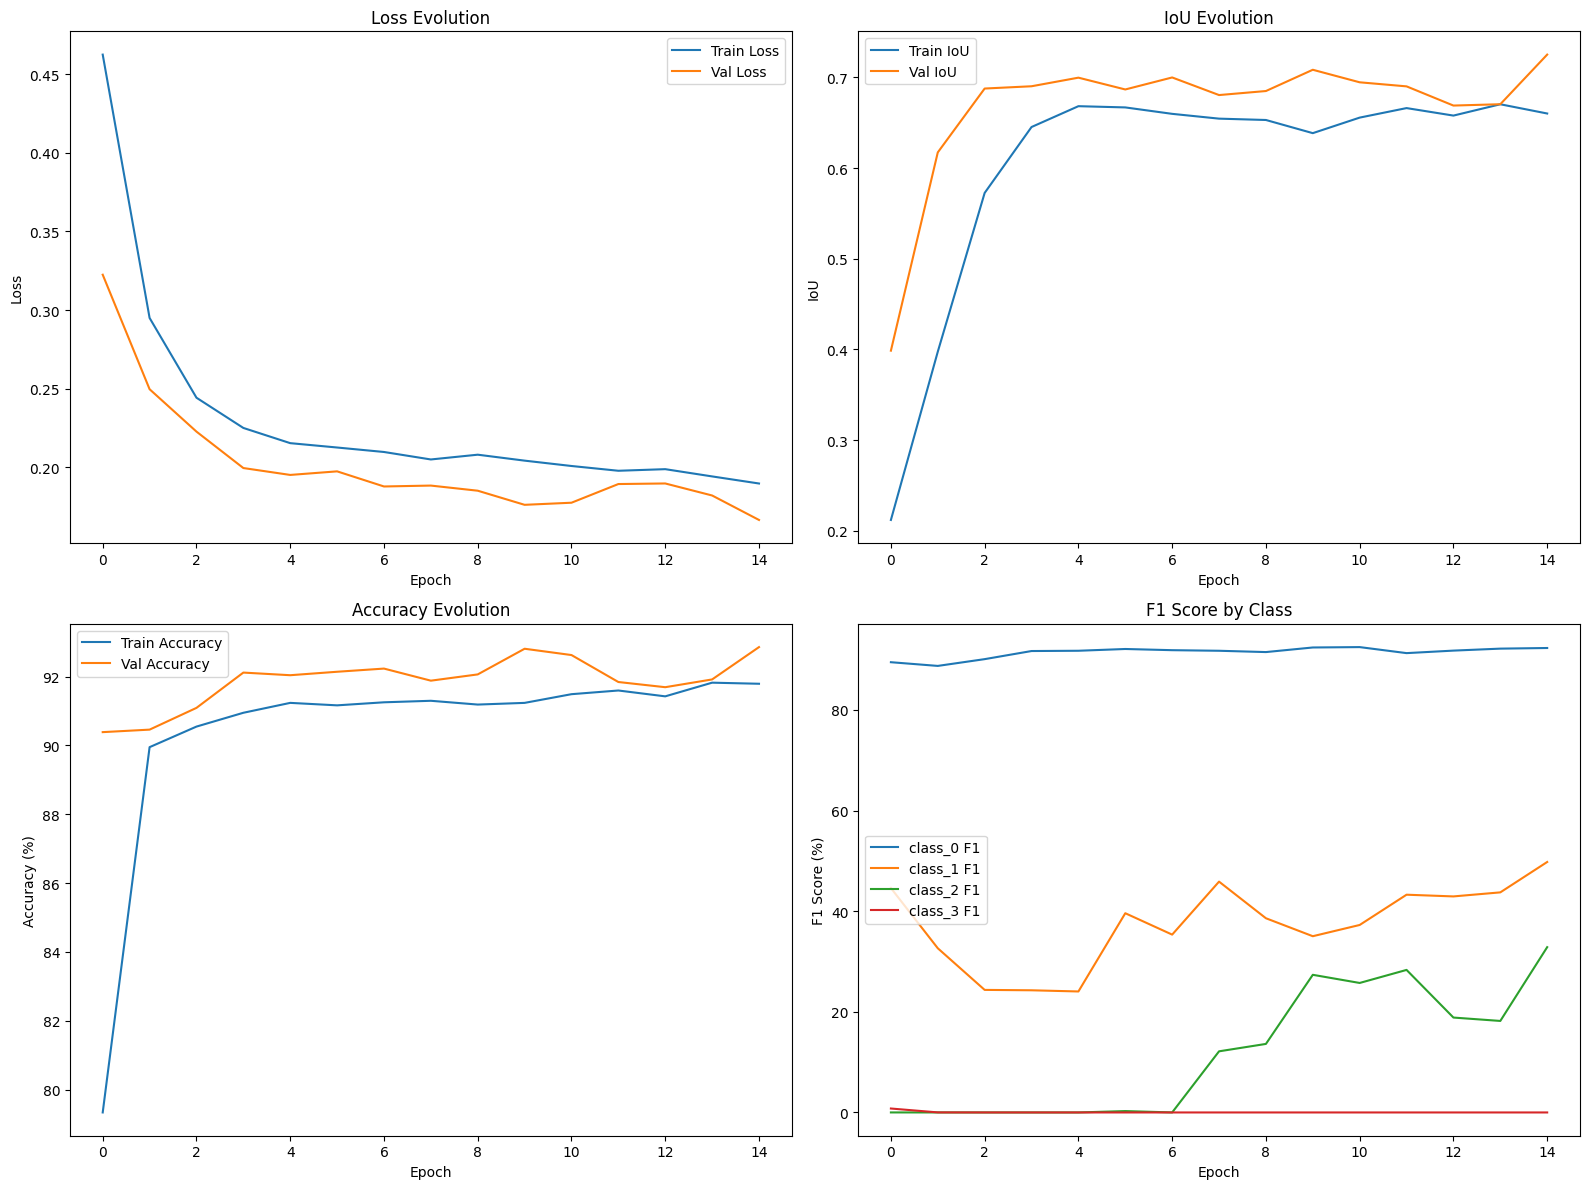

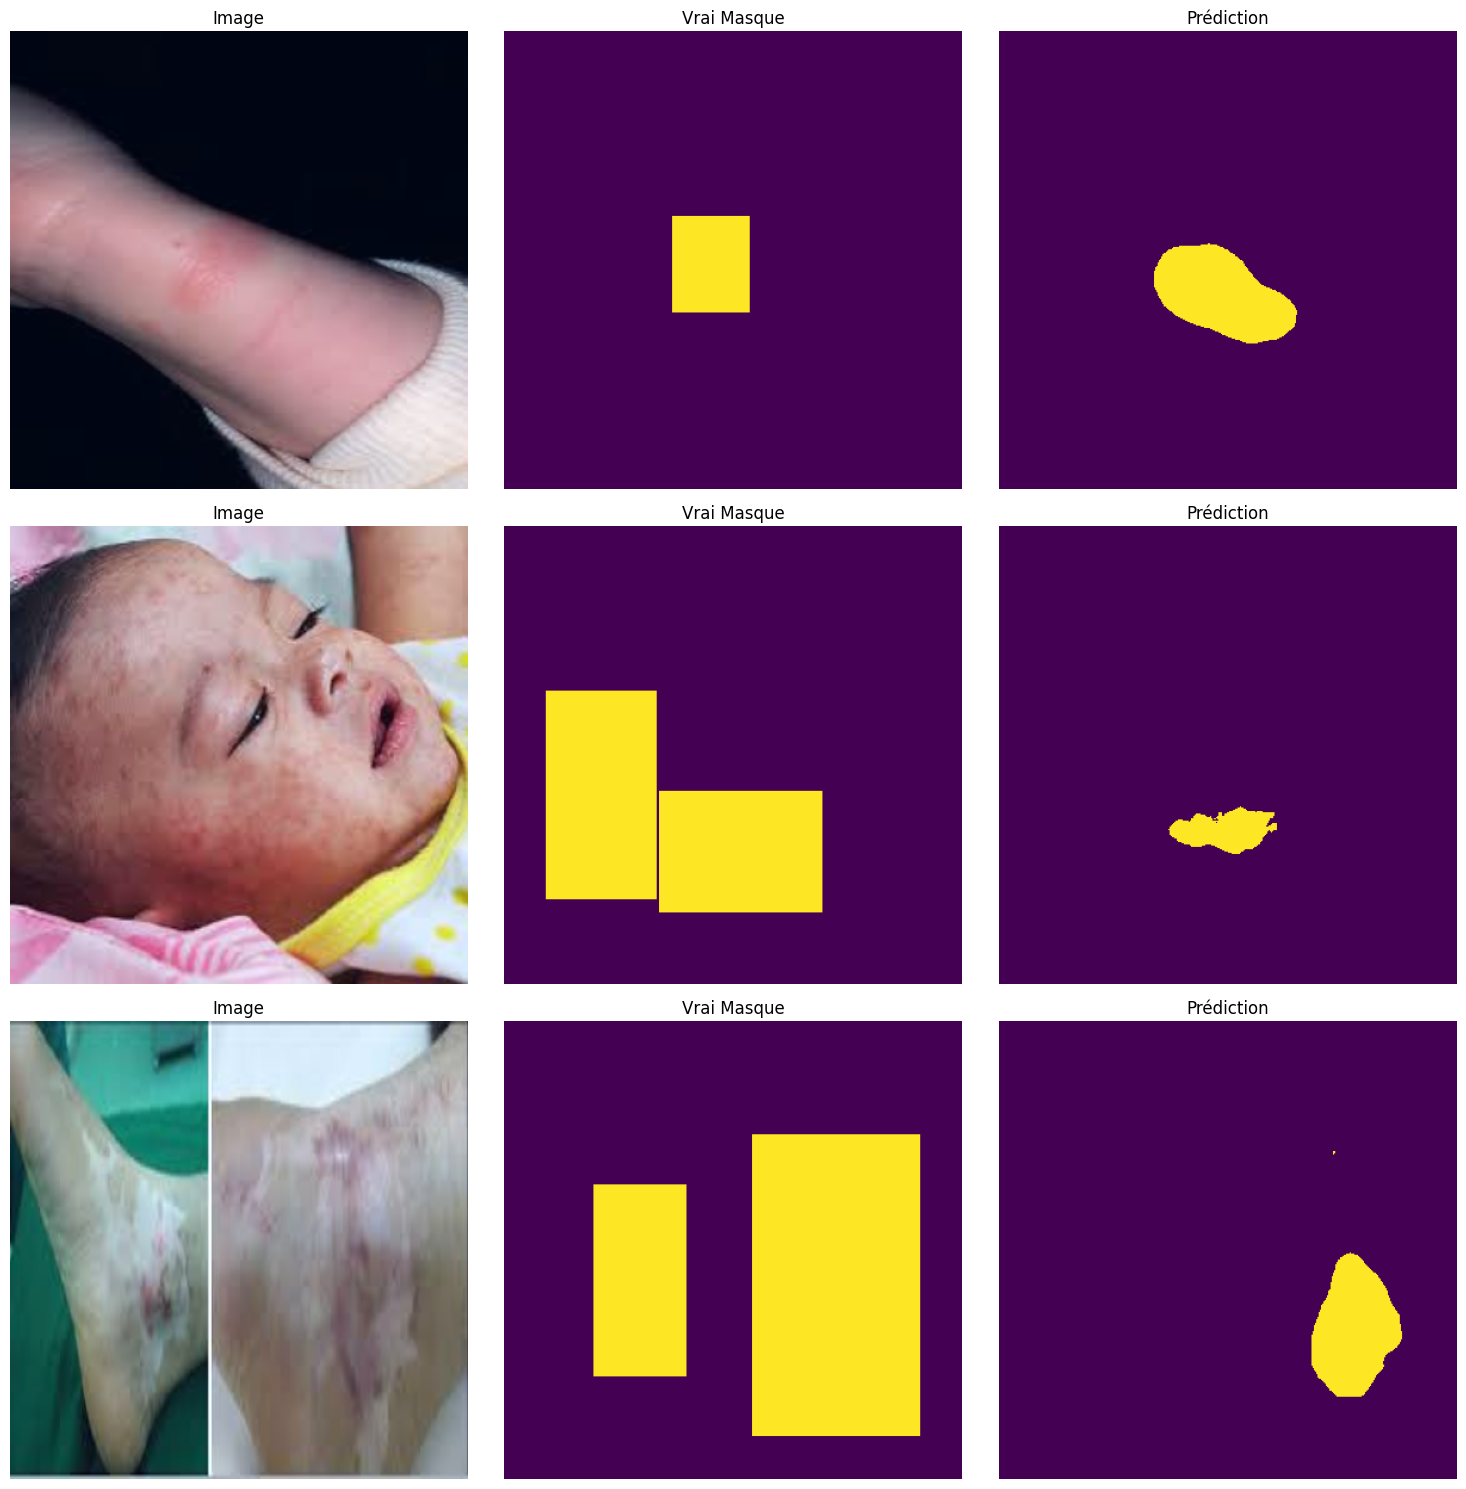

Mémoire GPU utilisée: 0.00 GB
Mémoire GPU réservée: 0.00 GB

Fold 2/3
Mémoire GPU utilisée: 0.00 GB
Mémoire GPU réservée: 0.00 GB
⚠️ Utilisation de 612 échantillons d'entraînement (75%)
Taille de l'ensemble d'entraînement: 612
Taille de l'ensemble de validation: 409
Utilisation de l'architecture resnet50 comme encodeur


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

⚠️ Réduction du nombre d'époques à 15

Époque 1/15
Mémoire GPU utilisée: 0.14 GB
Mémoire GPU réservée: 0.16 GB


Entraînement:   0%|          | 0/153 [00:00<?, ?it/s]

...

Entraînement:   0%|          | 0/153 [00:00<?, ?it/s]

Mémoire GPU utilisée: 0.42 GB
Mémoire GPU réservée: 0.56 GB


Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Train Loss: 0.2072, Train IoU: 0.6783, Train Accuracy: 91.25%
Val Loss: 0.2211, Val IoU: 0.6717, Val Accuracy: 90.31%

Métriques par classe (top 3):
class_0 - P: 86.34%, R: 93.34%, F1: 89.43%
class_1 - P: 44.18%, R: 40.81%, F1: 37.68%
class_2 - P: 0.00%, R: 0.00%, F1: 0.00%
EarlyStopping counter: 2 out of 10

Temps d'entraînement total: 14.23 minutes
Mémoire GPU utilisée: 0.42 GB
Mémoire GPU réservée: 0.56 GB


Validation:   0%|          | 0/50 [00:00<?, ?it/s]

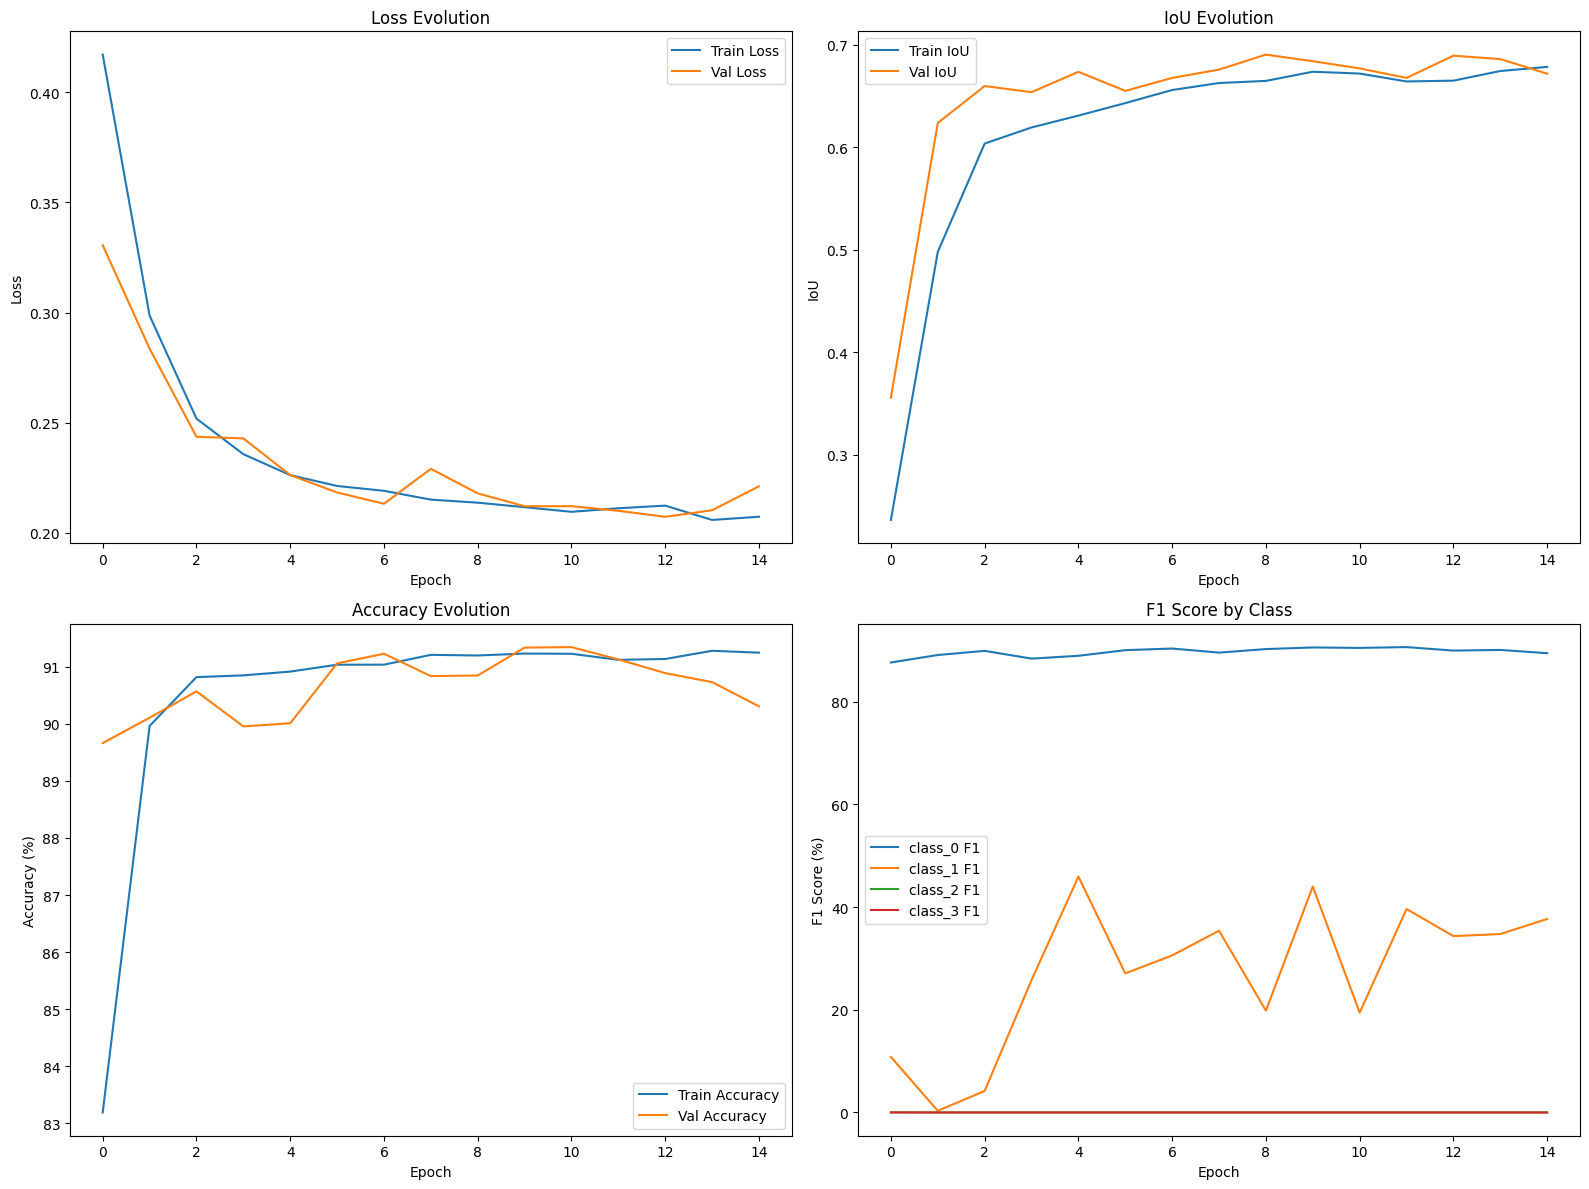

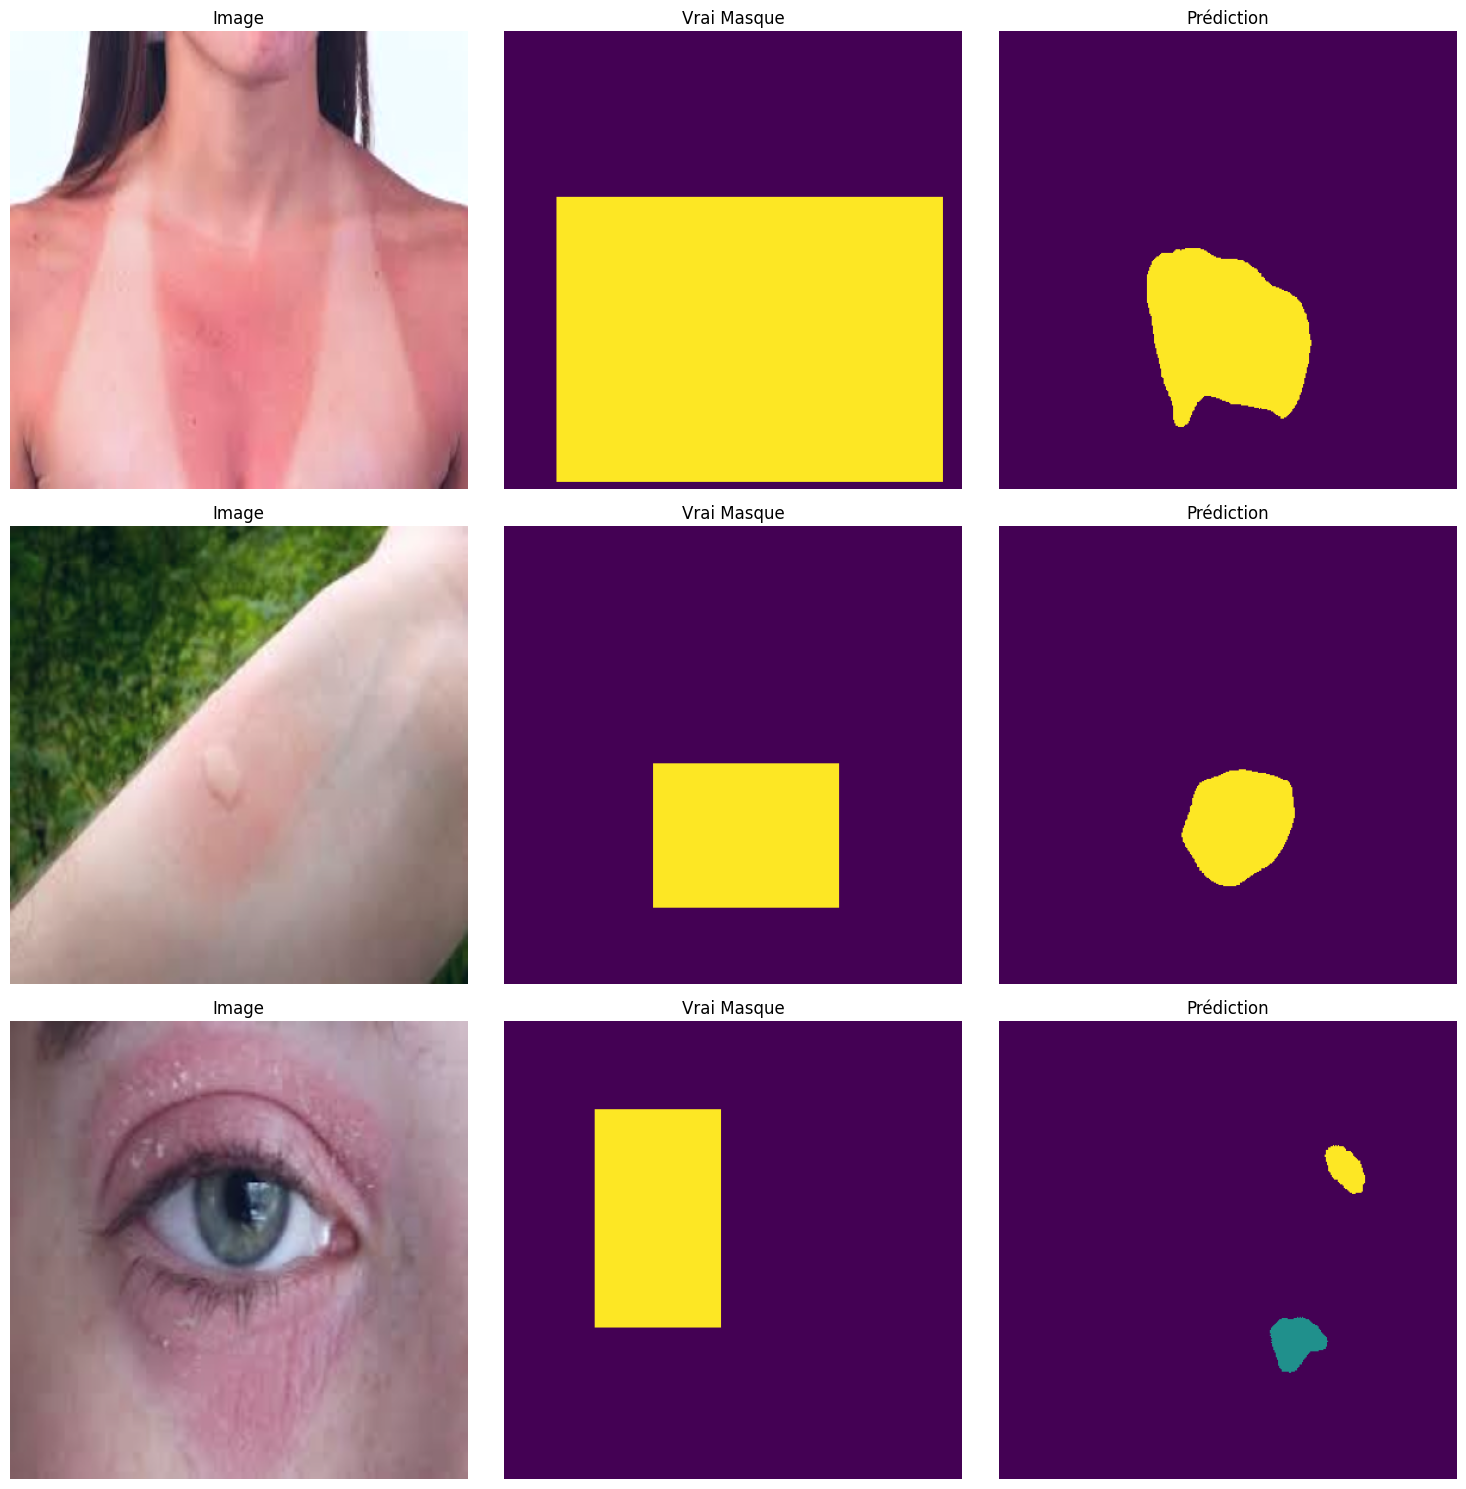

Mémoire GPU utilisée: 0.00 GB
Mémoire GPU réservée: 0.00 GB

Fold 3/3
Mémoire GPU utilisée: 0.00 GB
Mémoire GPU réservée: 0.00 GB
⚠️ Utilisation de 612 échantillons d'entraînement (75%)
Taille de l'ensemble d'entraînement: 612
Taille de l'ensemble de validation: 409
Utilisation de l'architecture resnet50 comme encodeur
⚠️ Réduction du nombre d'époques à 15

Époque 1/15
Mémoire GPU utilisée: 0.14 GB
Mémoire GPU réservée: 0.16 GB


Entraînement:   0%|          | 0/153 [00:00<?, ?it/s]

Mémoire GPU utilisée: 0.42 GB
Mémoire GPU réservée: 0.51 GB


Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Train Loss: 0.4600, Train IoU: 0.1879, Train Accuracy: 81.80%
Val Loss: 0.3874, Val IoU: 0.2030, Val Accuracy: 89.40%

Métriques par classe (top 3):
class_0 - P: 86.08%, R: 91.37%, F1: 88.37%
class_1 - P: 3.74%, R: 0.59%, F1: 0.95%
class_2 - P: 1.65%, R: 0.09%, F1: 0.17%
Validation loss decreased (-0.387400 --> -0.387400). Saving model...

Époque 2/15
Mémoire GPU utilisée: 0.42 GB
Mémoire GPU réservée: 0.51 GB


...

Entraînement:   0%|          | 0/153 [00:00<?, ?it/s]

Mémoire GPU utilisée: 0.42 GB
Mémoire GPU réservée: 0.51 GB


Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Train Loss: 0.2089, Train IoU: 0.6771, Train Accuracy: 91.19%
Val Loss: 0.1950, Val IoU: 0.6935, Val Accuracy: 91.73%

Métriques par classe (top 3):
class_0 - P: 88.18%, R: 94.55%, F1: 91.06%
class_1 - P: 37.49%, R: 26.13%, F1: 27.85%
class_2 - P: 0.00%, R: 0.00%, F1: 0.00%
EarlyStopping counter: 5 out of 10

Temps d'entraînement total: 14.91 minutes
Mémoire GPU utilisée: 0.42 GB
Mémoire GPU réservée: 0.51 GB


Validation:   0%|          | 0/50 [00:00<?, ?it/s]

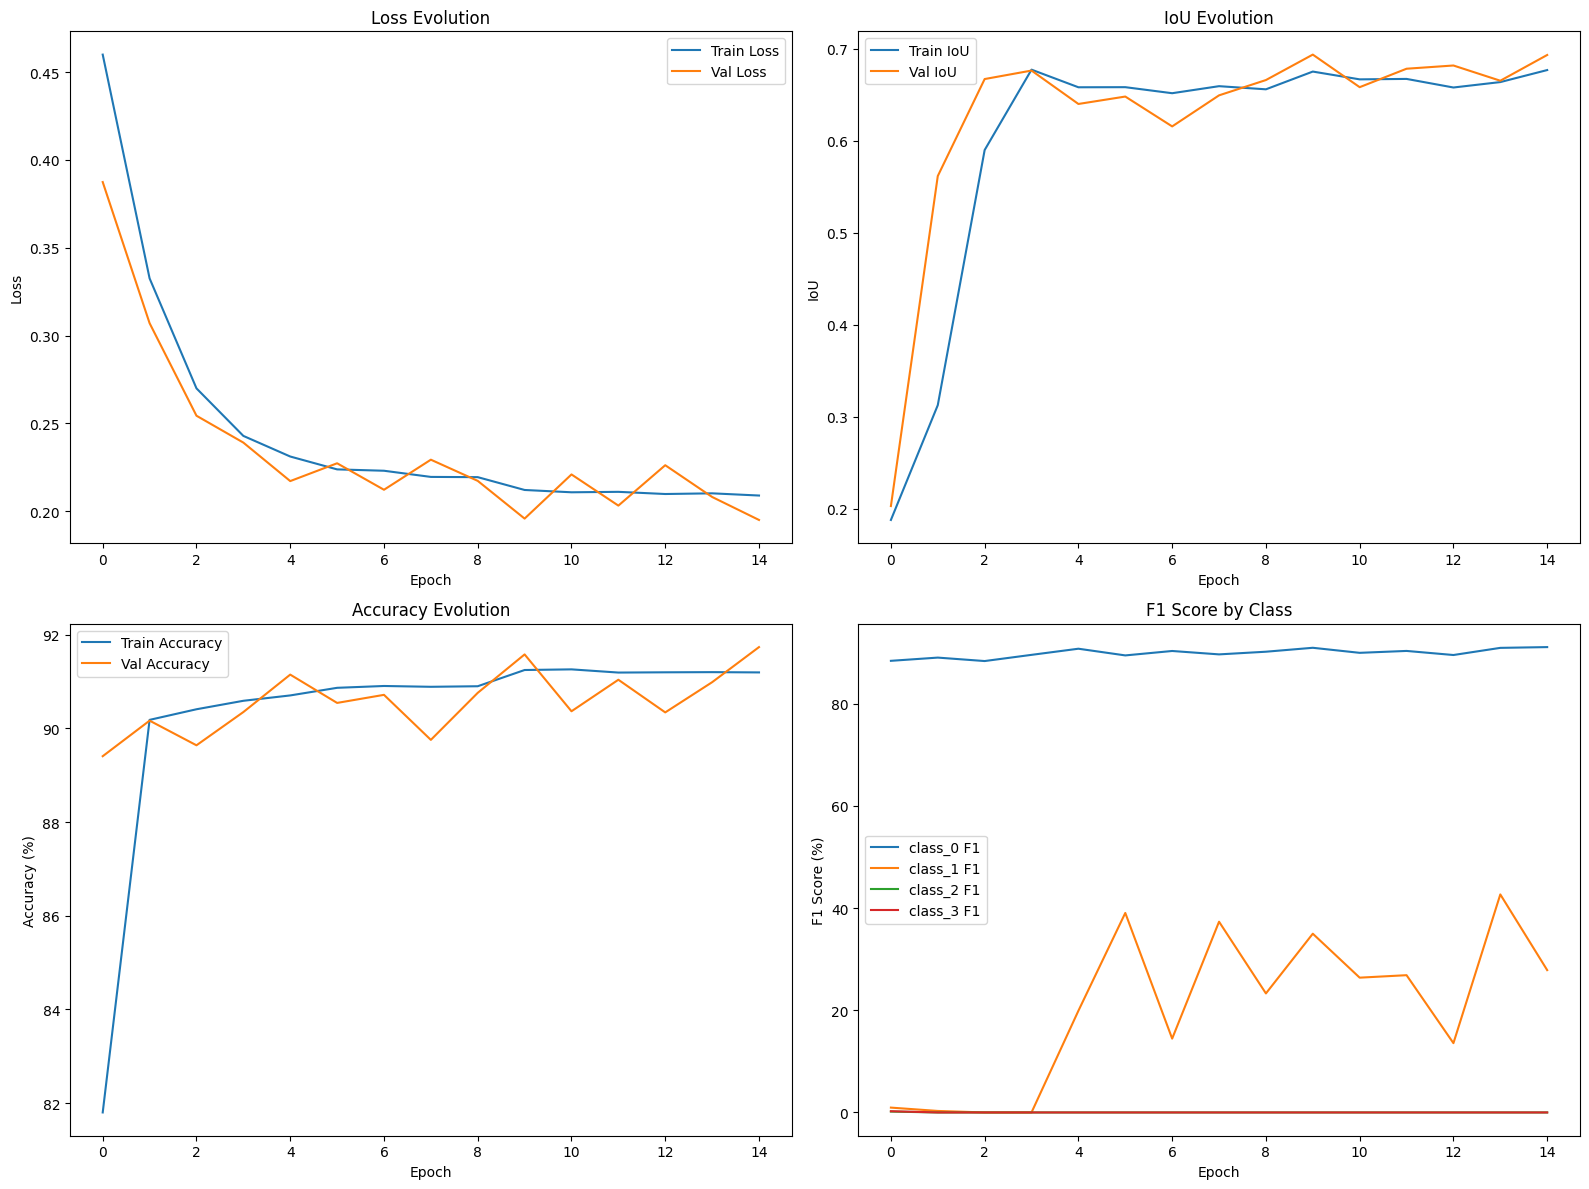

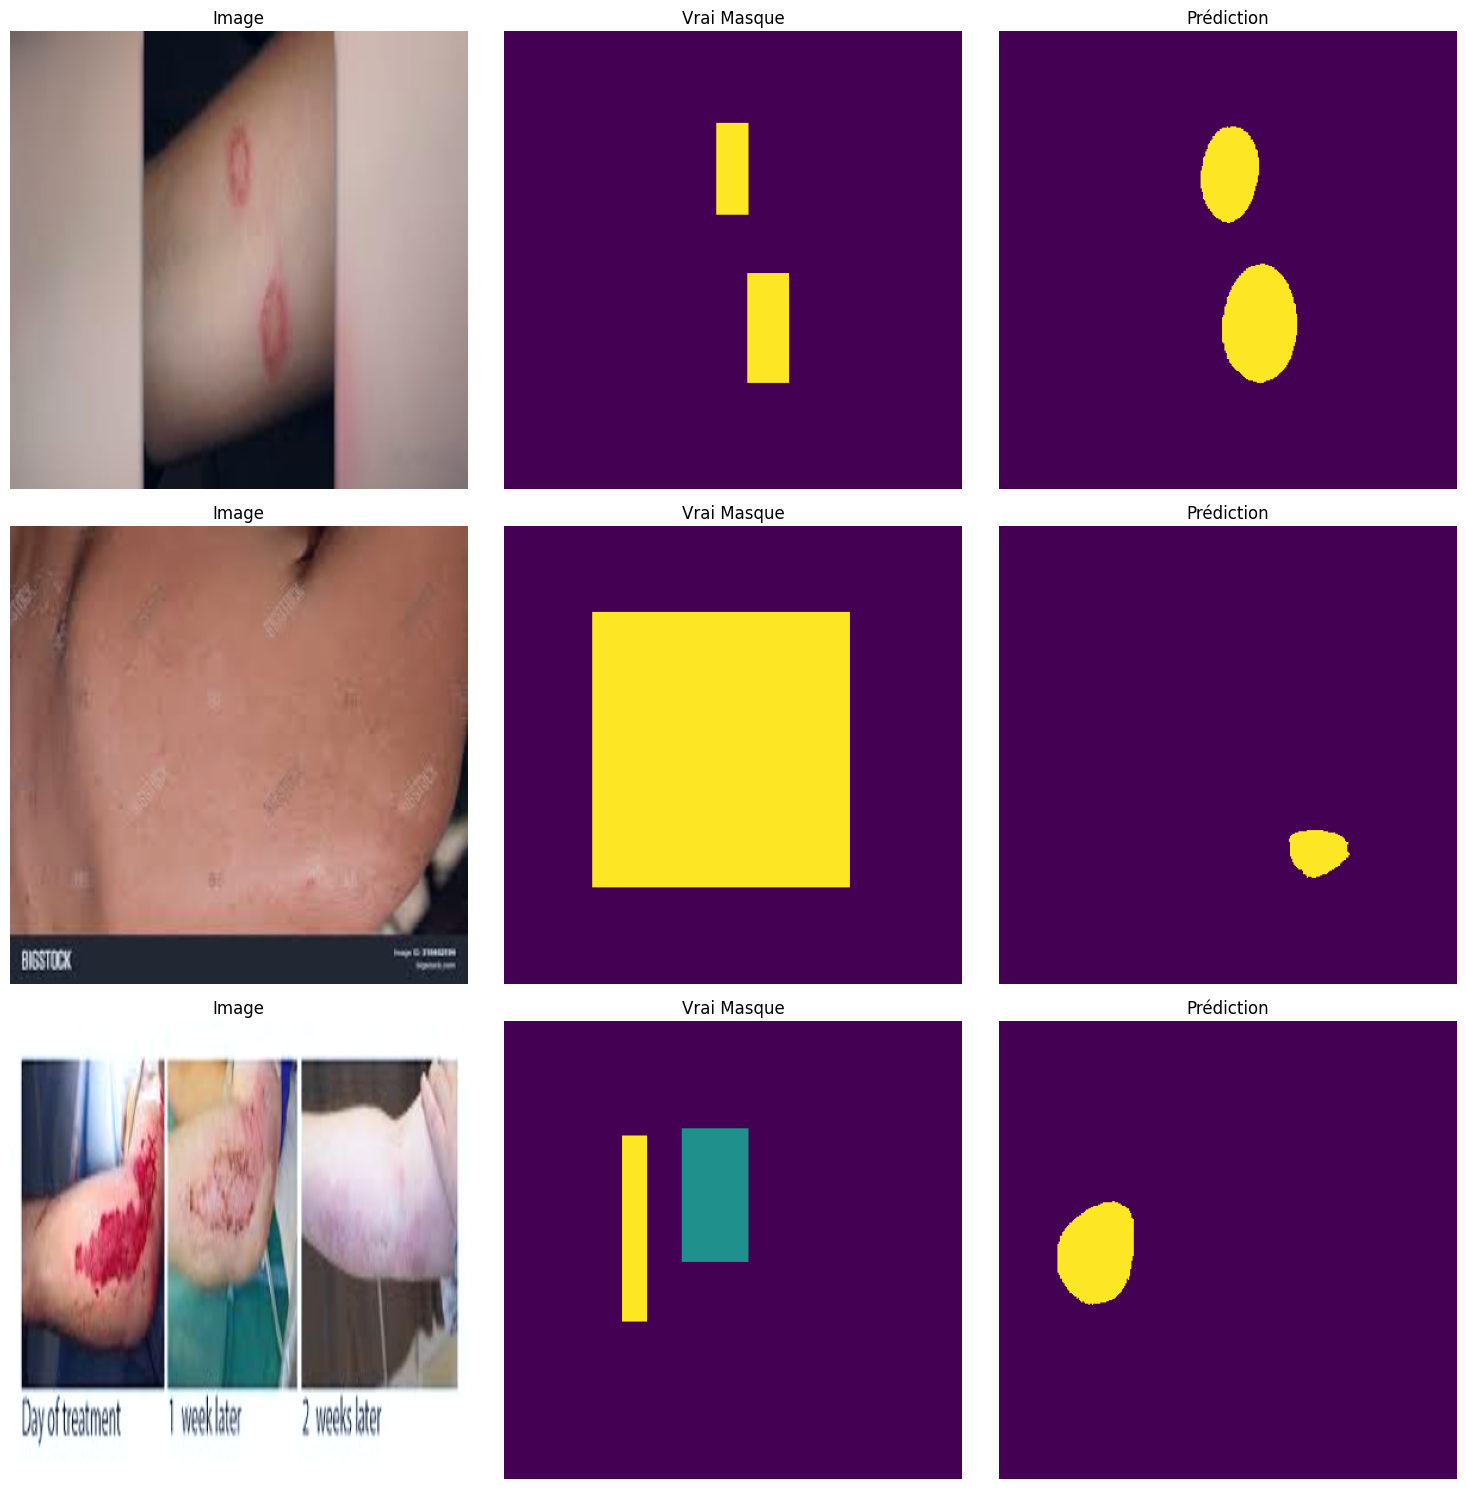

Mémoire GPU utilisée: 0.00 GB
Mémoire GPU réservée: 0.00 GB

Résultats de la validation croisée:
Perte moyenne: 0.1971 ± 0.0153
IoU moyen: 0.6939 ± 0.0134
Précision moyenne: 91.52% ± 0.57%

La précision moyenne est supérieure à 80% !
Entraînement du modèle final sur l'ensemble des données...
Mémoire GPU utilisée: 0.00 GB
Mémoire GPU réservée: 0.00 GB
Utilisation de l'architecture légère resnet18 comme encodeur


ValueError: Model depth is 5, but you provide `decoder_channels` for 4 blocks.

In [ ]:
if __name__ == "__main__":
    # Configuration Colab pour le GPU
    try:
        configure_colab_for_gpu()
    except:
        print("⚠️ Impossible de configurer l'environnement Colab")

    # Activation de la précision mixte
    scaler = use_mixed_precision()

    # Lancement du processus d'entraînement
    main()

In [ ]:
if __name__ == "__main__":
    # Configuration Colab pour le GPU
    try:
        configure_colab_for_gpu()
    except:
        print("⚠️ Impossible de configurer l'environnement Colab")

    # Activation de la précision mixte
    scaler = use_mixed_precision()

    # Lancement du processus d'entraînement
    main()

In [ ]:
def train_deeplabv3_model():
    """
    Fonction principale d'entraînement optimisée pour le modèle DeepLabV3+
    avec des optimisations pour gérer la mémoire GPU dans Colab
    """
    # Libérer la mémoire au début
    free_memory()

    # Réduire la taille d'image pour économiser la mémoire
    global IMG_SIZE
    IMG_SIZE_REDUCED = 384  # Au lieu de 512
    IMG_SIZE = IMG_SIZE_REDUCED
    print(f"Utilisation d'une taille d'image réduite: {IMG_SIZE_REDUCED}x{IMG_SIZE_REDUCED}")

    # Réduction de la taille du batch
    REDUCED_BATCH_SIZE = 4  # Réduire le batch size (ajuster selon votre GPU)
    print(f"⚠️ Réduction de la taille du batch à {REDUCED_BATCH_SIZE}")

    # Création des dataloaders avec une taille d'échantillon réduite
    try:
        # Récupération des chemins des fichiers
        image_paths, annotation_paths = get_file_paths()

        # Vérifier si les données sont disponibles
        if len(image_paths) == 0:
            print("Aucune paire image-annotation trouvée. Vérifiez le chemin des données.")
            return None

        # Si la mémoire est critique, utiliser un sous-ensemble des données
        sample_size = min(len(image_paths), 300)  # Limiter à 300 images max
        if sample_size < len(image_paths):
            print(f"⚠️ Utilisation d'un sous-ensemble de {sample_size} images sur {len(image_paths)}")
            indices = np.random.choice(len(image_paths), sample_size, replace=False)
            image_paths = [image_paths[i] for i in indices]
            annotation_paths = [annotation_paths[i] for i in indices]

        # Transformations optimisées
        train_transforms, val_transforms = get_augmentations()

        # Séparation des données en ensembles d'entraînement et de validation
        train_img_paths, val_img_paths, train_anno_paths, val_anno_paths = train_test_split(
            image_paths, annotation_paths, test_size=0.2, random_state=SEED
        )

        # Création des datasets
        train_dataset = SkinBurnDataset(train_img_paths, train_anno_paths, transforms=train_transforms)
        val_dataset = SkinBurnDataset(val_img_paths, val_anno_paths, transforms=val_transforms)

        # Création des dataloaders optimisés
        train_loader = optimize_dataloader(
            train_dataset,
            batch_size=REDUCED_BATCH_SIZE,
            num_workers=2  # Réduire le nombre de workers
        )

        val_loader = optimize_dataloader(
            val_dataset,
            batch_size=REDUCED_BATCH_SIZE,
            num_workers=2  # Réduire le nombre de workers
        )

        print(f"Taille de l'ensemble d'entraînement: {len(train_dataset)}")
        print(f"Taille de l'ensemble de validation: {len(val_dataset)}")
    except Exception as e:
        print(f"Erreur lors de la création des dataloaders: {e}")
        return None

    # Initialisation du modèle DeepLabV3+ avec gestion des erreurs
    try:
        model = create_deeplabv3_model()
        print("Modèle DeepLabV3+ créé avec succès!")
    except Exception as e:
        print(f"Échec de la création du modèle: {e}")
        # Essayer une solution alternative pour la création du modèle
        try:
            print("Tentative de création d'un modèle plus léger...")
            from segmentation_models_pytorch import DeepLabV3Plus
            model = DeepLabV3Plus(
                encoder_name="mobilenet_v2",  # Encoder plus léger
                encoder_weights="imagenet",
                in_channels=3,
                classes=NUM_CLASSES + 1,
                activation=None
            )
            model = model.to(device)
            print("Modèle léger DeepLabV3+ créé avec succès!")
        except Exception as e2:
            print(f"Échec de la création du modèle alternatif: {e2}")
            free_memory()
            return None

    # Définition de la fonction de perte et de l'optimiseur
    criterion = DiceBCELoss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

    # Scheduler plus efficace pour la mémoire
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, verbose=True, min_lr=1e-6
    )

    # Réduire le nombre d'époques si problème de mémoire
    REDUCED_EPOCHS = max(5, NUM_EPOCHS // 2)  # Moitié des époques, minimum 5
    print(f"⚠️ Réduction du nombre d'époques à {REDUCED_EPOCHS}")

    # Chemin pour les checkpoints
    checkpoint_path = os.path.join(BASE_PATH, 'best_deeplabv3_model.pt')

    # Vérifier si un modèle existant est disponible pour continuer l'entraînement
    if os.path.exists(checkpoint_path):
        try:
            model.load_state_dict(torch.load(checkpoint_path))
            print(f"Modèle préexistant chargé à partir de {checkpoint_path}")
        except Exception as e:
            print(f"Impossible de charger le modèle préexistant: {e}")

    # Early stopping pour éviter le surapprentissage
    early_stopping = EarlyStopping(
        patience=PATIENCE,
        delta=0.001,
        checkpoint_path=checkpoint_path
    )

    # Initialisation des listes pour tracer les courbes (plus petites)
    train_losses = []
    val_losses = []
    train_ious = []
    val_ious = []

    # Boucle d'entraînement avec gestion des erreurs
    for epoch in range(REDUCED_EPOCHS):
        print(f"\nEpoch {epoch+1}/{REDUCED_EPOCHS}")

        try:
            # Libérer la mémoire avant chaque époque
            free_memory()

            # Entraînement avec précision mixte pour économiser la mémoire
            model.train()
            total_loss = 0
            total_iou = 0

            # Utiliser le scaler pour la précision mixte
            scaler = torch.cuda.amp.GradScaler()

            for images, masks in tqdm(train_loader, desc="Entraînement"):
                images = images.to(device)
                masks = masks.to(device)

                # Forward pass avec précision mixte
                with torch.cuda.amp.autocast():
                    outputs = model(images)
                    loss = criterion(outputs, masks)

                # Backward pass et optimisation avec scaling
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

                # Calcul de l'IoU
                with torch.no_grad():
                    iou_metrics = calculate_iou(outputs, masks)

                # Mise à jour des métriques
                total_loss += loss.item()
                total_iou += iou_metrics["mean_iou"]

            # Calcul des moyennes
            train_loss = total_loss / len(train_loader)
            train_iou = total_iou / len(train_loader)

            # Validation avec optimisation de mémoire
            model.eval()
            val_loss, val_iou = optimized_validate_epoch(model, val_loader, criterion, device)

            # Mise à jour du scheduler
            scheduler.step(val_loss)

            # Enregistrement des métriques (seulement les 10 dernières époques pour économiser la mémoire)
            if epoch >= REDUCED_EPOCHS - 10:
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                train_ious.append(train_iou)
                val_ious.append(val_iou)

            # Affichage des résultats
            print(f"Train Loss: {train_loss:.4f} - Train IoU: {train_iou:.4f}")
            print(f"Val Loss: {val_loss:.4f} - Val IoU: {val_iou:.4f}")

            # Early stopping
            early_stopping(val_loss, model)
            if early_stopping.early_stop:
                print("Early stopping activé. Arrêt de l'entraînement.")
                break

        except RuntimeError as e:
            if "CUDA out of memory" in str(e):
                print(f"⚠️ CUDA out of memory à l'époque {epoch+1}. Tentative de récupération...")
                free_memory()
                # Réduire encore le batch size pour les prochaines époques
                for param_group in optimizer.param_groups:
                    param_group['lr'] = param_group['lr'] * 0.5
                continue
            else:
                print(f"Erreur d'exécution à l'époque {epoch+1}: {e}")
                break
        except Exception as e:
            print(f"Erreur inattendue à l'époque {epoch+1}: {e}")
            break

    # Charger le meilleur modèle
    try:
        model.load_state_dict(torch.load(checkpoint_path))
        print(f"Meilleur modèle chargé depuis {checkpoint_path}")
    except Exception as e:
        print(f"Impossible de charger le meilleur modèle: {e}")

    # Tracer les courbes uniquement si l'entraînement a abouti
    if len(train_losses) > 0:
        try:
            # Libérer la mémoire avant de tracer
            free_memory()

            plt.figure(figsize=(12, 6))

            plt.subplot(1, 2, 1)
            plt.plot(range(1, len(train_losses)+1), train_losses, 'b-', label='Train Loss')
            plt.plot(range(1, len(val_losses)+1), val_losses, 'r-', label='Val Loss')
            plt.xlabel('Dernières Époques')
            plt.ylabel('Loss')
            plt.title('Evolution de la perte - DeepLabV3+')
            plt.legend()
            plt.grid(True)

            plt.subplot(1, 2, 2)
            plt.plot(range(1, len(train_ious)+1), train_ious, 'b-', label='Train IoU')
            plt.plot(range(1, len(val_ious)+1), val_ious, 'r-', label='Val IoU')
            plt.xlabel('Dernières Époques')
            plt.ylabel('IoU')
            plt.title('Evolution de l\'IoU - DeepLabV3+')
            plt.legend()
            plt.grid(True)

            plt.tight_layout()
            plt.savefig(os.path.join(BASE_PATH, 'training_curves_deeplabv3.png'))
            plt.show()

            # Calculer la précision des classes uniquement si le modèle est bon
            try:
                # Évaluation finale avec un sous-ensemble du dataset pour éviter les problèmes de mémoire
                val_subset = torch.utils.data.Subset(
                    val_dataset,
                    indices=np.random.choice(len(val_dataset), min(len(val_dataset), 50), replace=False)
                )
                val_subset_loader = optimize_dataloader(val_subset, batch_size=2, num_workers=1)

                # Calculer la précision pour chaque classe
                class_accuracies = optimized_validate_class_accuracy(model, val_subset_loader, device)

                # Afficher les résultats sous forme de texte plutôt que graphique
                print(f"\nPrécision par classe - DeepLabV3+")
                class_names = ["Fond", "1er degré", "2ème degré", "3ème degré"]
                for i, class_name in enumerate(class_names):
                    if class_name in class_accuracies:
                        print(f"{class_name}: {class_accuracies[class_name]:.2f}%")
            except Exception as e:
                print(f"Erreur lors du calcul des précisions par classe: {e}")
        except Exception as e:
            print(f"Erreur lors du traçage des courbes: {e}")

    # Libérer la mémoire à la fin
    free_memory()

    return model

def optimized_validate_epoch(model, dataloader, criterion, device):
    """
    Fonction d'évaluation optimisée pour une époque
    """
    model.eval()
    total_loss = 0
    total_iou = 0
    total_accuracy = 0
    batch_count = 0

    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="Validation"):
            images = images.to(device)
            masks = masks.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, masks)

            # Calcul de l'IoU
            iou_metrics = calculate_iou(outputs, masks)

            # Calcul de l'accuracy
            preds = torch.argmax(torch.sigmoid(outputs), dim=1)
            true_masks = torch.argmax(masks, dim=1)
            correct = (preds == true_masks).sum().item()
            total_pixels = true_masks.numel()
            accuracy = 100.0 * correct / total_pixels

            # Mise à jour des métriques
            total_loss += loss.item()
            total_iou += iou_metrics["mean_iou"]
            total_accuracy += accuracy
            batch_count += 1

            # Libérer immédiatement la mémoire
            del images, masks, outputs, preds, true_masks
            if hasattr(torch.cuda, 'empty_cache'):
                torch.cuda.empty_cache()

    # Calcul des moyennes
    metrics = {
        "loss": total_loss / max(1, batch_count),
        "iou": total_iou / max(1, batch_count),
        "accuracy": total_accuracy / max(1, batch_count)
    }

    return metrics

def optimized_validate_class_accuracy(model, val_loader, device):
    """
    Calcule la précision pour chaque classe sur l'ensemble de validation avec optimisation mémoire
    """
    model.eval()
    class_correct = [0] * (NUM_CLASSES + 1)  # +1 pour le fond
    class_total = [0] * (NUM_CLASSES + 1)

    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc="Calcul de la précision par classe"):
            images = images.to(device)
            masks = masks.to(device)

            # Forward pass
            outputs = model(images)
            preds = torch.argmax(torch.sigmoid(outputs), dim=1)
            true_masks = torch.argmax(masks, dim=1)

            # Mise à jour des compteurs par classe
            for c in range(NUM_CLASSES + 1):
                class_correct[c] += ((preds == c) & (true_masks == c)).sum().item()
                class_total[c] += (true_masks == c).sum().item()

            # Libérer la mémoire
            del images, masks, outputs, preds, true_masks
            if hasattr(torch.cuda, 'empty_cache'):
                torch.cuda.empty_cache()

    # Calcul des précisions
    class_names = ["Fond", "1er degré", "2ème degré", "3ème degré"]
    class_accuracies = {}

    for i in range(NUM_CLASSES + 1):
        if class_total[i] > 0:
            accuracy = 100.0 * class_correct[i] / class_total[i]
        else:
            accuracy = 0.0
        class_accuracies[class_names[i]] = accuracy
        print(f"Précision pour {class_names[i]}: {accuracy:.2f}%")

    return class_accuracies

def optimize_dataloader(dataset, batch_size=4, num_workers=2, pin_memory=True):
    """
    Crée un DataLoader optimisé pour la mémoire
    """
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=False,  # Garder le dernier batch même incomplet
        persistent_workers=False  # Désactive les workers persistants pour économiser la mémoire
    )

def visualize_deeplabv3_predictions(model, val_loader, num_samples=3):
    """
    Visualise les prédictions du modèle DeepLabV3+ sur quelques exemples
    avec optimisation de la mémoire
    """
    model.eval()

    # Libérer la mémoire avant de commencer
    free_memory()

    # Limiter le nombre d'échantillons pour économiser la mémoire
    num_samples = min(num_samples, 3)

    # Liste des couleurs pour les différentes classes (normalisées entre 0 et 1)
    colors = [
        (0, 0, 0),           # Fond: noir
        (1.0, 0, 0),         # Classe 0 (1er degré): rouge
        (0, 1.0, 0),         # Classe 1 (2ème degré): vert
        (0, 0, 1.0)          # Classe 2 (3ème degré): bleu
    ]

    # Noms des classes pour l'affichage
    class_names = ["Fond", "1er degré", "2ème degré", "3ème degré"]

    # Réduire la taille de la figure pour économiser la mémoire
    plt.figure(figsize=(12, 4 * num_samples))

    sample_count = 0
    with torch.no_grad():
        # Limiter les échantillons du dataloader pour économiser la mémoire
        for i, (images, masks) in enumerate(val_loader):
            if sample_count >= num_samples:
                break

            # Traiter un seul échantillon à la fois
            for j in range(min(1, images.size(0))):
                # Transférer sur le GPU
                image = images[j:j+1].to(device)
                mask = masks[j:j+1].to(device)

                # Prédiction
                output = model(image)
                output = torch.sigmoid(output)
                pred = torch.argmax(output, dim=1)

                # Récupérer sur CPU
                img = image[0].cpu().permute(1, 2, 0).numpy()
                img = np.clip(img * 0.229 + 0.485, 0, 1)  # Dénormalisation

                true_mask = torch.argmax(mask[0], dim=0).cpu().numpy()
                pred_mask = pred[0].cpu().numpy()

                # Libérer immédiatement la mémoire GPU
                del image, mask, output, pred
                if hasattr(torch.cuda, 'empty_cache'):
                    torch.cuda.empty_cache()

                # Création des masques colorés
                true_mask_colored = np.zeros((true_mask.shape[0], true_mask.shape[1], 3))
                pred_mask_colored = np.zeros((pred_mask.shape[0], pred_mask.shape[1], 3))

                for cls_idx, color in enumerate(colors):
                    true_mask_colored[true_mask == cls_idx] = color
                    pred_mask_colored[pred_mask == cls_idx] = color

                # Affichage
                plt.subplot(num_samples, 3, sample_count*3+1)
                plt.imshow(img)
                plt.title("Image originale")
                plt.axis('off')

                plt.subplot(num_samples, 3, sample_count*3+2)
                plt.imshow(true_mask_colored)
                plt.title("Vérité terrain")
                plt.axis('off')

                plt.subplot(num_samples, 3, sample_count*3+3)
                plt.imshow(pred_mask_colored)
                plt.title("Prédiction DeepLabV3+")
                plt.axis('off')

                sample_count += 1
                if sample_count >= num_samples:
                    break

    # Légende des couleurs
    handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in colors]
    plt.figlegend(handles, class_names, loc='lower center', ncol=4, fontsize=10)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)

    # Sauvegarder l'image avec une résolution réduite
    plt.savefig(os.path.join(BASE_PATH, 'prediction_samples_deeplabv3.png'), dpi=100)
    plt.show()

    # Libérer la mémoire
    plt.close()
    free_memory()